<a href="https://colab.research.google.com/github/varshamqa/AutomateBrowserSerVSC-M1/blob/master/AI_ML_GreedBoostingAlgo_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Heart Diseases: What are the indicators?</div>


# 0. **Introduction** <a class="anchor" id="0"></a>
"Heart disease, also referred as cardiovascular diseases, is broad term used for diseases and conditions affecting the heart and circulatory system. It is a major cause of disability all around the world. Since heart is amongst the most vital organs of the body, its diseases affect other organs and part of the body as well. There are several different types and forms of heart diseases. The most common ones cause narrowing or blockage of the coronary arteries, malfunctioning in the valves of the heart, enlargement in the size of heart and several others leading to **heart failure** and **heart attack**."

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color:#4e4e4e; padding: 1em; margin:24px;">

<font color="white" size=+1.0><b>Key facts according to WHO (World Health Organaizations)</b></font>  
        
<ul>
<li> Cardiovascular diseases (CVDs) are the leading cause of death globally.
<li> An estimated 17.9 million people died from CVDs in 2019, representing 32% of all global deaths. Of these deaths, 85% were due to heart attack and stroke.
<li> Over three quarters of CVD deaths take place in low- and middle-income countries.
<li> Out of the 17 million premature deaths (under the age of 70) due to noncommunicable diseases in 2019, 38% were caused by CVDs.
<li> Most cardiovascular diseases can be prevented by addressing behavioural risk factors such as tobacco use, unhealthy diet and obesity, physical inactivity and harmful use of alcohol.
<li> It is important to detect cardiovascular disease as early as possible so that management with counselling and medicines can begin.                                                                                                                                 
    
</ul>        
</blockquote>

#### **Objectives**
This notebook has two main objectives:
* Explore the heart disease dataset using exploratory data analysis (EDA)
* Exercise with classification algorithms for prediction (modelling)
---







**1. Exploratory Data Analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [3]:
data=pd.read_csv('/content/heart_boosting algo.csv')
print('Shape of the data is ', data.shape)

Shape of the data is  (303, 14)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
data.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


**Note**: From the data types we see that all features are int64/float64. But that is because some of the categorical features including the target (has disease/no disease) are already label encoded for us. We will, in the section below, see a detailed decreption of the features.

In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1.1 **Data Dictionary** <a class="anchor" id="1.1"></a>

1. age: age in years
2. sex: sex
    * 1 = male
    * 0 = female
3. cp: chest pain type
    * Value 0: typical angina
    * Value 1: atypical angina
    * Value 2: non-anginal pain
    * Value 3: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl)
    * 1 = true;
    * 0 = false
7. restecg: resting electrocardiographic results
    * Value 0: normal
    * Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    * Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved
9. exang: exercise induced angina
    * 1 = yes
    * 0 = no
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    * Value 0: upsloping
    * Value 1: flat
    * Value 2: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal:
    * 0 = `error (in the original dataset 0 maps to NaN's)`
    * 1 = fixed defect
    * 2 = normal
    * 3 = reversable defect
14. target (the lable):
    * 0 = no disease,
    * 1 = disease
---    
**Note on the target label**:

`Diagnosis of heart disease (angiographic disease status)
Value 0: < 50% diameter narrowing
Value 1: > 50% diameter narrowing`
    
**Notes from the discussion forum of the dataset**:

* data #93, 159, 164, 165 and 252 have `ca=4` which is incorrect. In the original Cleveland dataset they are NaNs.
* data #49 and 282 have `thal = 0`, also incorrect. They are also NaNs in the original dataset.

**Action**:  Drop the faulty data! (7 data entry will be dropped)

## 1.2 **Data pre-processing** <a class="anchor" id="1.2"></a>
### 1.2.1 Drop faulty data
Based on our investigation we did above, we will drop 7 rows.

In [5]:
data=data[data['ca']< 4] #drop the wrong ca values
data=data[data['thal']> 0] # drop the wong thal value
print(f'The length of the data now is {len(data)} instead of 303!')

The length of the data now is 296 instead of 303!


In [ ]:
data.shape

(296, 14)

### 1.2.2 Rename columns for the sake of clarity
* The feature names in the dataset are abbreviated and hard to understand their meaning. A full medical/technical name is hard enough to understand for most of us let alone their short form. So to make them a little bit easier to read we will, here under, change the column names of the data frame using information from the UCL data repository.
* We'll also replace the coded categories (0, 1, 2,..) to their medical meaning ('atypical angina', 'typical angina', etc. for example)

In [7]:
data=data.rename(
    columns=
    {
    'cp':'chest_pain',
    'exang':'exercise_induced_angina',
    'ca':'number_of_major_vessels',
    'fbs':'fasting_blood_sugar',
    'restecg':'resting_electocardiogram',
    'target':'heart_disease',
    'oldpeak':'st_depression',
    'thal':'thalassemia_types',
    'chol':'cholesterol',
    'slope':'st_slope',
    'thalach':'maximum_heart_rate_achieved',
    'age':'age_of_the_patient'},
errors='raise')

In [32]:
data.loc[data['sex']==0,'sex'] = 'female'
data.loc[data['sex']==1,'sex'] = 'male'

data['chest_pain'][data['chest_pain']==0] = 'typical angina'
data['chest_pain'][data['chest_pain']==1] = 'atypical angina'
data['chest_pain'][data['chest_pain']==2] = 'non-anginal pain'
data['chest_pain'][data['chest_pain']==3] = 'asympomatic'

data['fasting_blood_sugar'][data['fasting_blood_sugar']==0] = 'lower than 120mg/ml'
data['fasting_blood_sugar'][data['fasting_blood_sugar']==1] = 'greter than 120mg/ml'

data['resting_electocardiogram'][data['resting_electocardiogram']==0] = 'normal'
data['resting_electocardiogram'][data['resting_electocardiogram']==1] = 'ST-T wave abnormality'
data['resting_electocardiogram'][data['resting_electocardiogram']==2] = 'left ventricular hypertrophy'

data['exercise_induced_angina'][data['exercise_induced_angina']==0] = 'no'
data['exercise_induced_angina'][data['exercise_induced_angina']==1] = 'yes'

data['st_slope'][data['st_slope']==0] = 'upsloping'
data['st_slope'][data['st_slope']==1] = 'flat'
data['st_slope'][data['st_slope']==2] = 'downsloping'

data['thalassemia_types'][data['thalassemia_types']==1] = 'fixed defect'
data['thalassemia_types'][data['thalassemia_types']==2] ='normal'
data['thalassemia_types'][data['thalassemia_types']==3] ='reversable defect'

In [9]:
data.dtypes

,0
age_of_the_patient,int64
sex,object
chest_pain,object
trestbps,int64
cholesterol,int64
fasting_blood_sugar,object
resting_electocardiogram,object
maximum_heart_rate_achieved,int64
exercise_induced_angina,object
st_depression,float64


In [10]:
data.head()

,age_of_the_patient,sex,chest_pain,trestbps,cholesterol,fasting_blood_sugar,resting_electocardiogram,maximum_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessels,thalassemia_types,heart_disease
0,63,male,asympomatic,145,233,greter than 120mg/ml,normal,150,no,2.3,upsloping,0,normal,1
1,37,male,non-anginal pain,130,250,lower than 120mg/ml,ST-T wave abnormality,187,no,3.5,upsloping,0,2,1
2,41,female,atypical angina,130,204,lower than 120mg/ml,normal,172,no,1.4,downsloping,0,2,1
3,56,male,atypical angina,120,236,lower than 120mg/ml,ST-T wave abnormality,178,no,0.8,downsloping,0,2,1
4,57,female,typical angina,120,354,lower than 120mg/ml,ST-T wave abnormality,163,yes,0.6,downsloping,0,2,1


### 1.2.3 Grouping Features (by data type)
* As we have seen above there are three datatypes i.e **object**, **int** and **floats**. Let's group them according to type.


In [18]:
num_feats = ['age_of_the_patient', 'cholesterol', 'trestbps', 'maximum_heart_rate_achieved', 'st_depression']
nom_feats=['chest_pain','resting_electocardiogram','st_slope','thalassemia_types']
bin_feats=['sex','fasting_blood_sugar','exercise_induced_angina','heart_disease']

cat_feats = nom_feats + bin_feats

## 1.3 **Exploring Features/Target** <a class="anchor" id="1.3"></a>

In this section we'll investigate all the features (including the target) in detail. We will look at the statistical summary when possible and the distributions of some of them as well, starting from the target.

### 1.3.1 Target distribution

We observe that the target is fairly balanced with ~46% with no heart disease and ~54% with heart disease. So no need to worry about target imbalance.


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay , classification_report
from sklearn.metrics import recall_score, accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import shap

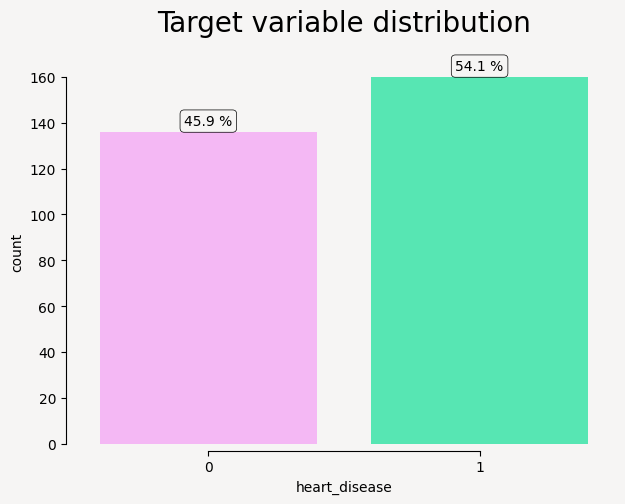

In [37]:
mypal= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA']

plt.figure(figsize=(7, 5),facecolor='#F6F5F4')
total = float(len(data))
ax = sns.countplot(x=data['heart_disease'], palette=mypal[1::4])
ax.set_facecolor('#F6F5F4')

for p in ax.patches:

    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.1f} %'.format((height/total)*100), ha="center",
           bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

ax.set_title('Target variable distribution', fontsize=20, y=1.05)
sns.despine(right=True)
sns.despine(offset=5, trim=True)

### 1.3.2 Numerical Features

#### Statistical summary

For the numerical features we can apply the handy pandas `data.describe()` method and get the global statistical summary. Key figures are highlighted below.

In [38]:
data[num_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
age_of_the_patient,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
cholesterol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
trestbps,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
maximum_heart_rate_achieved,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
st_depression,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2


### **Statistical summary of the numerical features**

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">
   
<ul>
<font color="white" size=+1.0><b>Age</b></font> :
    <li> The average age in the dataset is 54.5 years
    <li> The oldest is 77 years, whereas the youngest is 29 years old
 <font color="white" size=+1.0><b>Cholesterol:</b></font>
    <li> The average registered cholestrol level is 247.15
    <li> Maximum level is 564 and the minimum level is 126.
    <li> <strong>Note</strong>: A healthy cholesterol level is $<200 mg/dl$ and usually high level of cholesterol is associated with heart disease.
<font color="white" size=+1.0><b>Resting blood pressure:</b></font>
    <li> 131 mean, 200 max and 94 min
<font color="white" size=+1.0><b>Max heart rate achieved:</b></font>
    <li> The abverage max heart rate registered is 149.5 bpm. The Maximum and the minumum are 202 and 71bpm respectively.
<font color="white" size=+1.0><b>St_depression:</b></font>
    <li> The average value of st_dpression is 1.06. Max is 6.2 and the minimum is 0.
<font color="white" size=+1.0><b>Number of major blood vessels:</b></font>
    <li> A maximum of 3 and a minimum of 0 major blood vessels are observed. The mean value is 0.68.
</ul>                                                                                                                                             
<blockquote>                                                                                                                                               

#### Distribution: Density plots

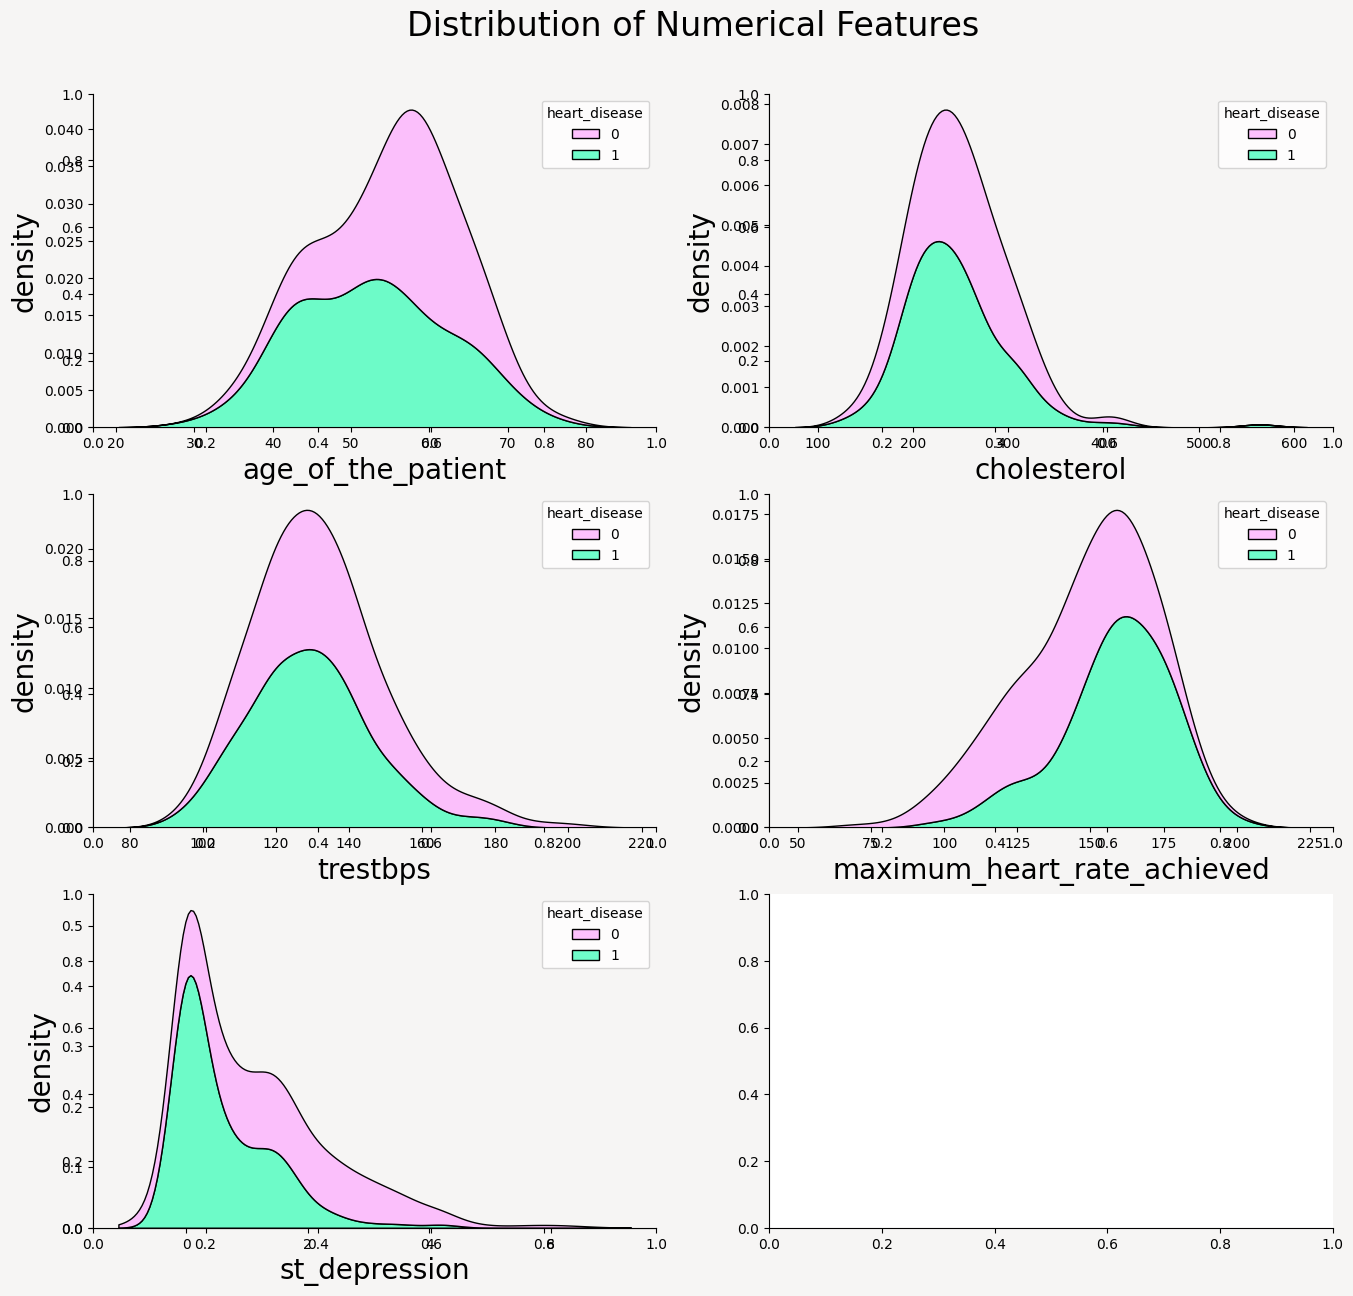

In [39]:
L = len(num_feats)
ncol= 2
nrow= int(np.ceil(L/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(16, 14),facecolor='#F6F5F4')
fig.subplots_adjust(top=0.92)

i = 1
for col in num_feats:
    plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')

    ax = sns.kdeplot(data=data, x=col, hue="heart_disease", multiple="stack", palette=mypal[1::4])
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel("density", fontsize=20)
    sns.despine(right=True)
    sns.despine(offset=0, trim=False)

    if col == 'num_major_vessels':
        sns.countplot(data=data, x=col, hue="heart_disease", palette=mypal[1::4])
        for p in ax.patches:
                height = p.get_height()
                ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.0f}'.format((height)),ha="center",
                      bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

    i = i +1
plt.suptitle('Distribution of Numerical Features' ,fontsize = 24);

#### Pair-plots

#### Selected Features

Below are reg-plots of some selected features showing the linear relation with Age, similar to the first column in the pair-plot above. We observe that:
- Except `maximum_heart_rate_achieved`, the others are positively and linearly related with `age` (albeit a weaker relation with `st_depression`).
- Younger patients with higher `maximum_heart_rate_achieved` are more likely to have a heart condition.
- Lower `st_depression` regardless of age is also likely an indication of a heart disease.


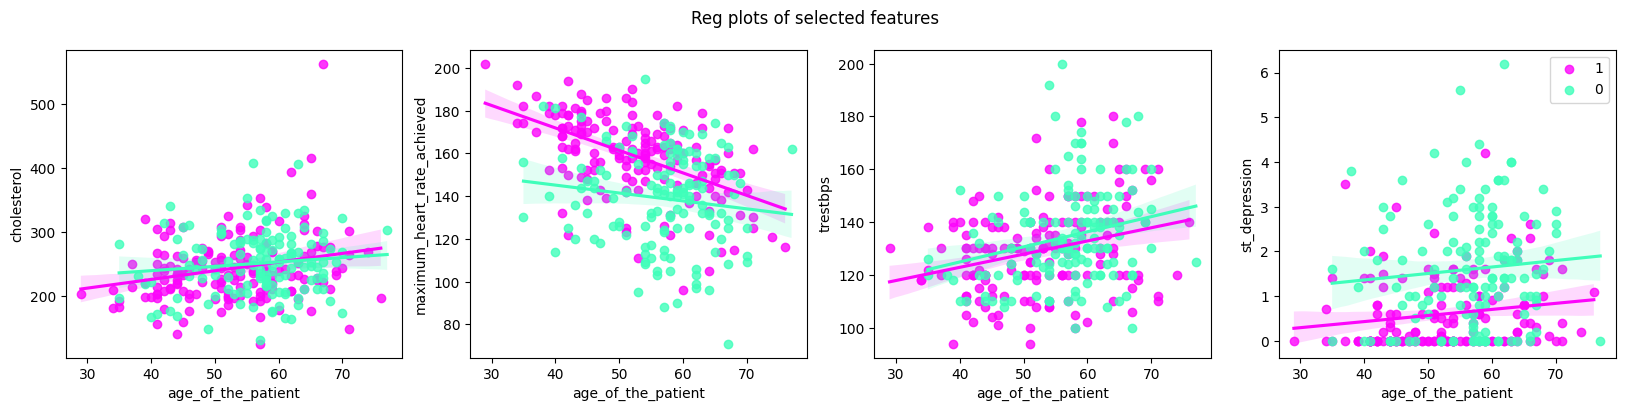

In [40]:
fig, ax = plt.subplots(1,4, figsize=(20, 4))
sns.regplot(data=data[data['heart_disease'] ==1], x='age_of_the_patient', y='cholesterol', ax = ax[0], color=mypal[0], label='1')
sns.regplot(data=data[data['heart_disease'] ==0], x='age_of_the_patient', y='cholesterol', ax = ax[0], color=mypal[5], label='0')
sns.regplot(data=data[data['heart_disease'] ==1], x='age_of_the_patient', y='maximum_heart_rate_achieved', ax = ax[1], color=mypal[0], label='1')
sns.regplot(data=data[data['heart_disease'] ==0], x='age_of_the_patient', y='maximum_heart_rate_achieved', ax = ax[1], color=mypal[5], label='0')
sns.regplot(data=data[data['heart_disease'] ==1], x='age_of_the_patient', y='trestbps', ax = ax[2], color=mypal[0], label='1')
sns.regplot(data=data[data['heart_disease'] ==0], x='age_of_the_patient', y='trestbps', ax = ax[2], color=mypal[5], label='0')
sns.regplot(data=data[data['heart_disease'] ==1], x='age_of_the_patient', y='st_depression', ax = ax[3], color=mypal[0], label='1')
sns.regplot(data=data[data['heart_disease'] ==0], x='age_of_the_patient', y='st_depression', ax = ax[3], color=mypal[5], label='0')
plt.suptitle('Reg plots of selected features')
plt.legend();

#### Distribution: Count plots

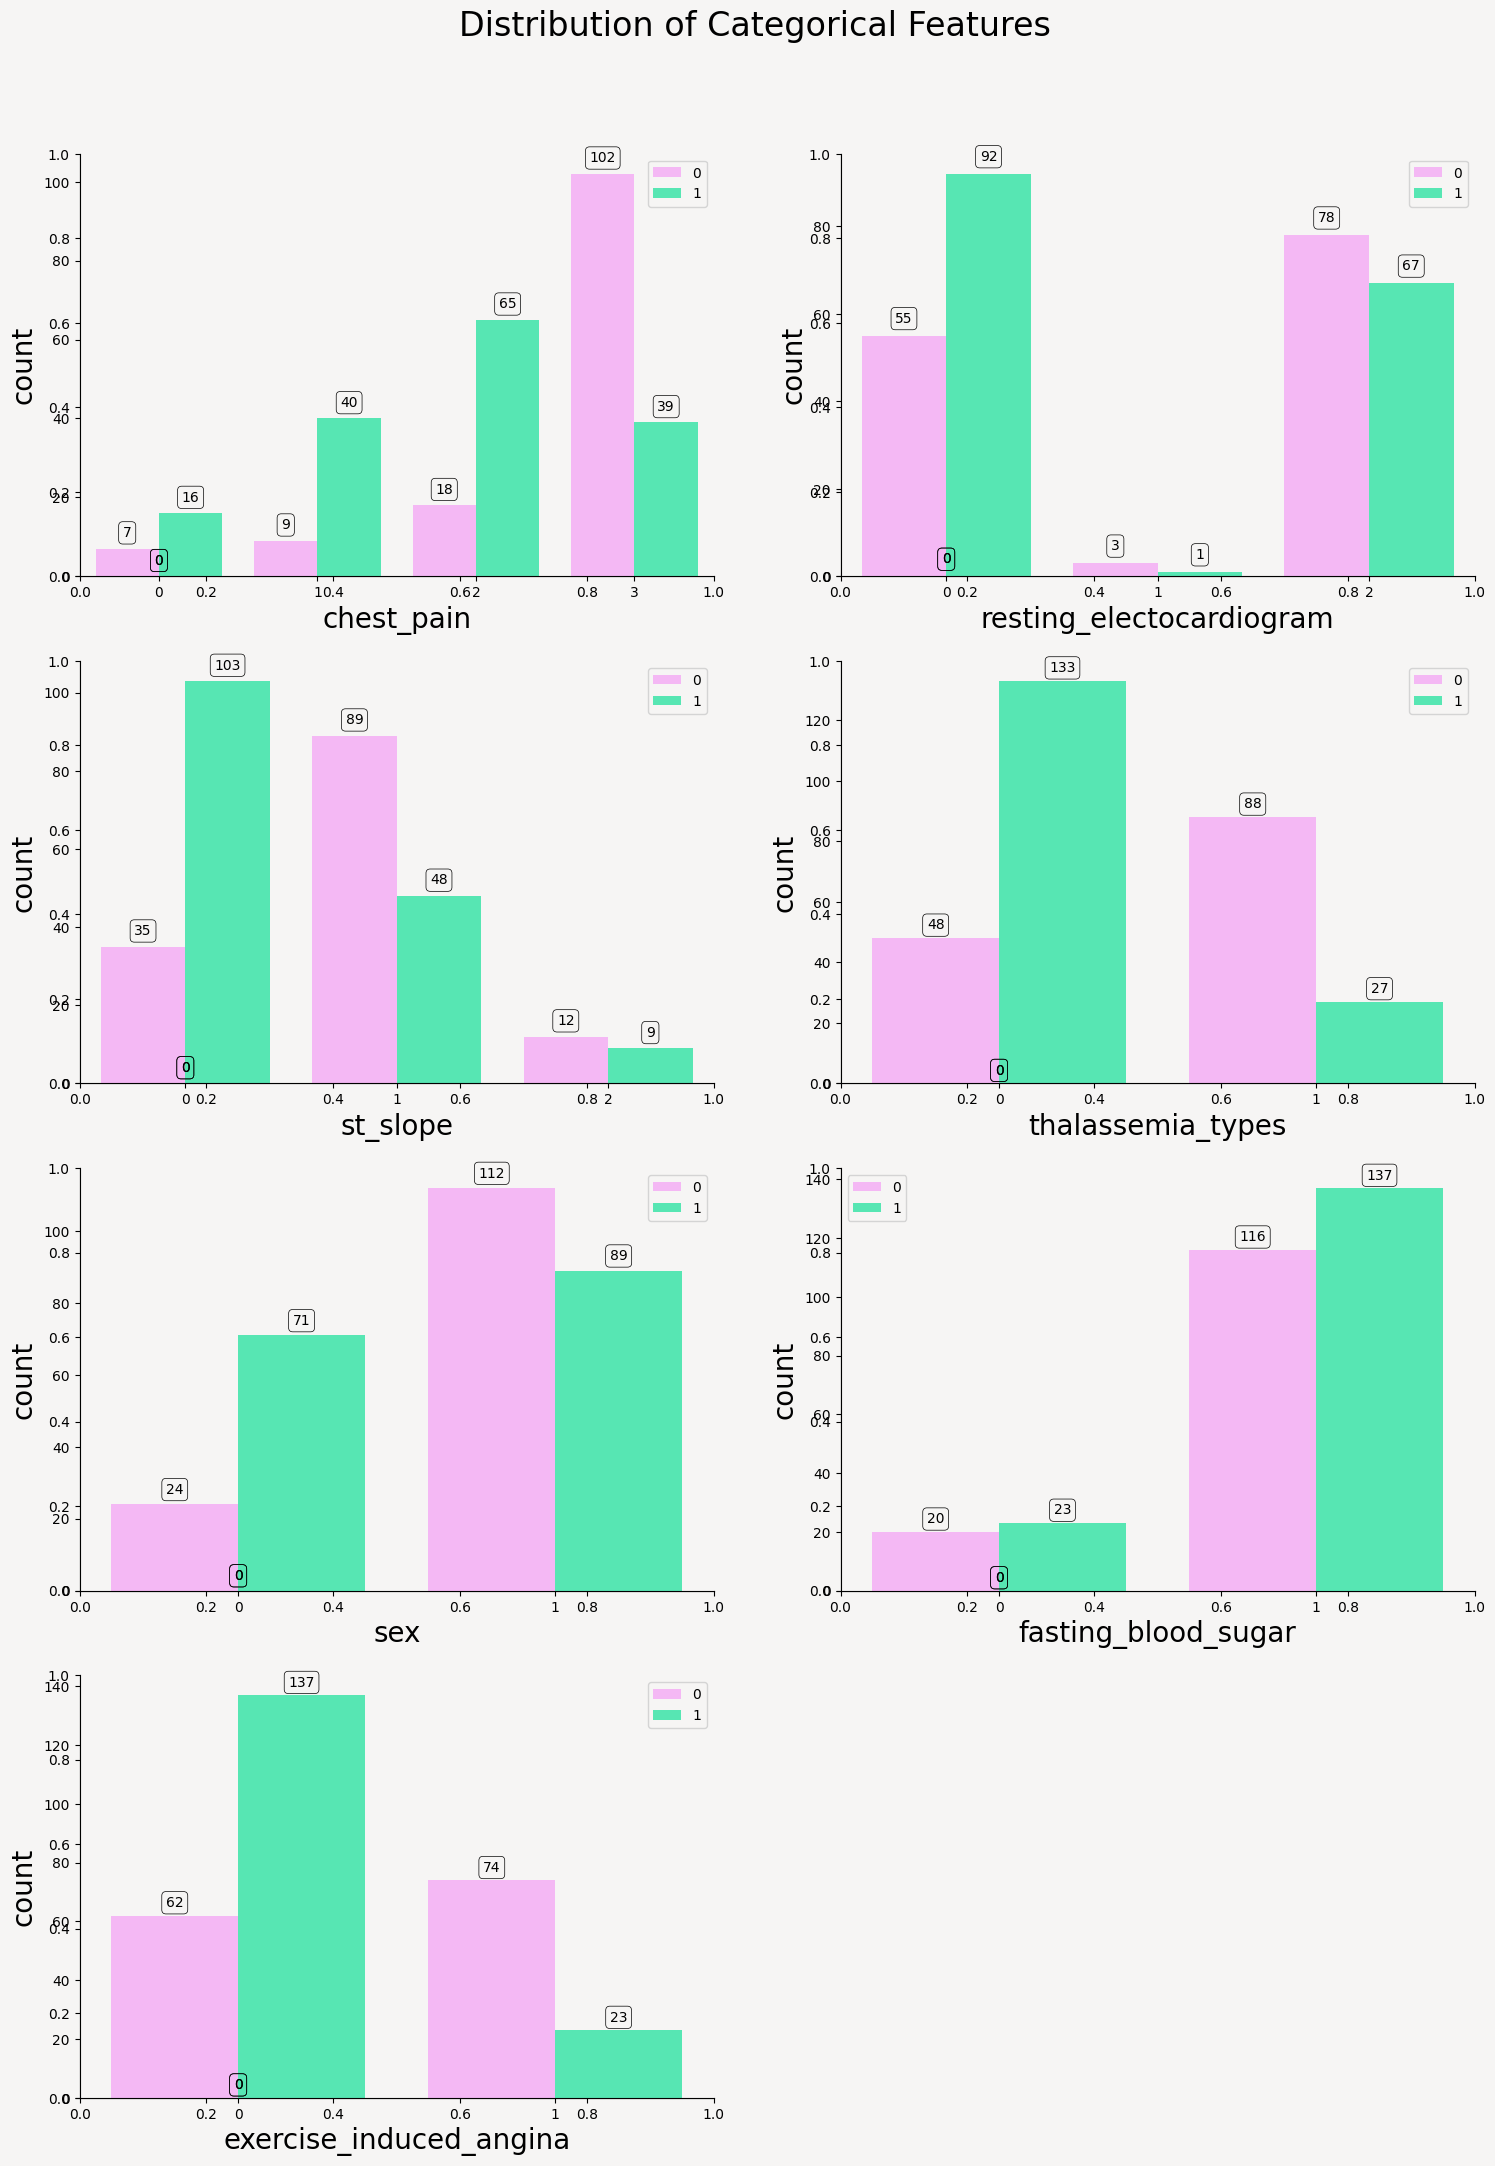

In [41]:
def count_plot(data, cat_feats):
    L = len(cat_feats)
    ncol= 2
    nrow= int(np.ceil(L/ncol))
    remove_last= (nrow * ncol) - L

    fig, ax = plt.subplots(nrow, ncol,figsize=(18, 24), facecolor='#F6F5F4')
    fig.subplots_adjust(top=0.92)
    ax.flat[-remove_last].set_visible(False)

    i = 1
    for col in cat_feats:
        plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')
        ax = sns.countplot(data=data, x=col, hue="heart_disease", palette=mypal[1::4])
        ax.set_xlabel(col, fontsize=20)
        ax.set_ylabel("count", fontsize=20)
        sns.despine(right=True)
        sns.despine(offset=0, trim=False)
        plt.legend(facecolor='#F6F5F4')

        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.0f}'.format((height)),ha="center",
                  bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

        i = i +1

    plt.suptitle('Distribution of Categorical Features' ,fontsize = 24)
    return 0

count_plot(data, cat_feats[0:-1]);

##  1.4 **Correlation Heatmaps** <a class="anchor" id="1.4"></a>

Correlation heatmap is a useful tool to graphyically represent how two features are related to eachother. Depending upon the data types of the features, we need to use the appropriate correlation coefficient calculation methods. Examples are pearson's correlation coefficient, point biserial correlation, cramers'V correlation and etc.

### 1.4.1 Pearson's correlation

* The Pearson correlation coefficient ― is a measure of linear correlation between two sets of data. It is the ratio between the covariance of two variables and the product of their standard deviations; thus it is essentially a normalised measurement of the covariance, such that the result always has a value between −1 and 1. ([ref. ](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient))

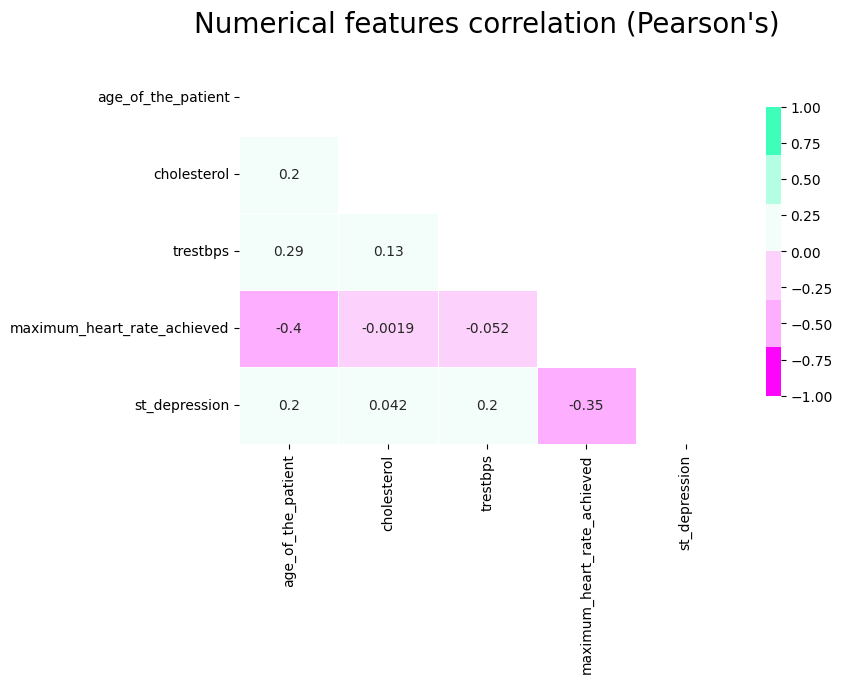

In [42]:
df_ = data[num_feats]
corr = df_.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(8, 5), facecolor=None)
cmap = sns.color_palette(mypal, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0, annot=True,
            square=False, linewidths=.5, cbar_kws={"shrink": 0.75})
ax.set_title("Numerical features correlation (Pearson's)", fontsize=20, y= 1.05);

- A point-biserial correlation is used to measure the strength and direction of the association that exists between **one continuous variable and one dichotomous variable**. It is a special case of the Pearson’s product-moment correlation, which is applied when you have two continuous variables, whereas in this case one of th### 1.4.2 Point biserial correlation
e variables is measured on a dichotomous scale [[ref. ](https://statistics.laerd.com/spss-tutorials/point-biserial-correlation-using-spss-statistics.php)].

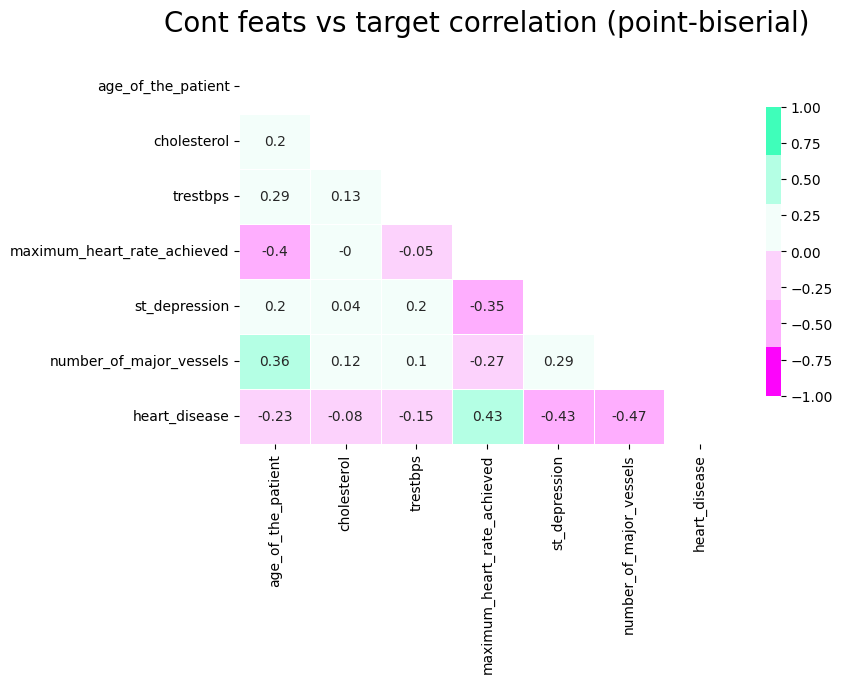

In [43]:
import scipy.stats as stats

feats_ = ['age_of_the_patient', 'cholesterol', 'trestbps', 'maximum_heart_rate_achieved', 'st_depression', 'number_of_major_vessels', 'heart_disease']

def point_biserial(x, y):
    pb = stats.pointbiserialr(x, y)
    return pb[0]

rows= []
for x in feats_:
    col = []
    for y in feats_ :
        pbs =point_biserial(data[x], data[y])
        col.append(round(pbs,2))
    rows.append(col)

pbs_results = np.array(rows)
DF = pd.DataFrame(pbs_results, columns = data[feats_].columns, index =data[feats_].columns)

mask = np.triu(np.ones_like(DF, dtype=bool))
corr = DF.mask(mask)

f, ax = plt.subplots(figsize=(8, 5), facecolor=None)
cmap = sns.color_palette(mypal, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1, center=0, annot=True,
            square=False, linewidths=.5, cbar_kws={"shrink": 0.75})
ax.set_title("Cont feats vs target correlation (point-biserial)", fontsize=20, y= 1.05);

### 1.4.3 Cramer's V correlation

* In statistics, Cramér's V is a measure of association between **two nominal variables**, giving a value between 0 and +1 (inclusive). It is based on Pearson's chi-squared statistic and was published by Harald Cramér in 1946.

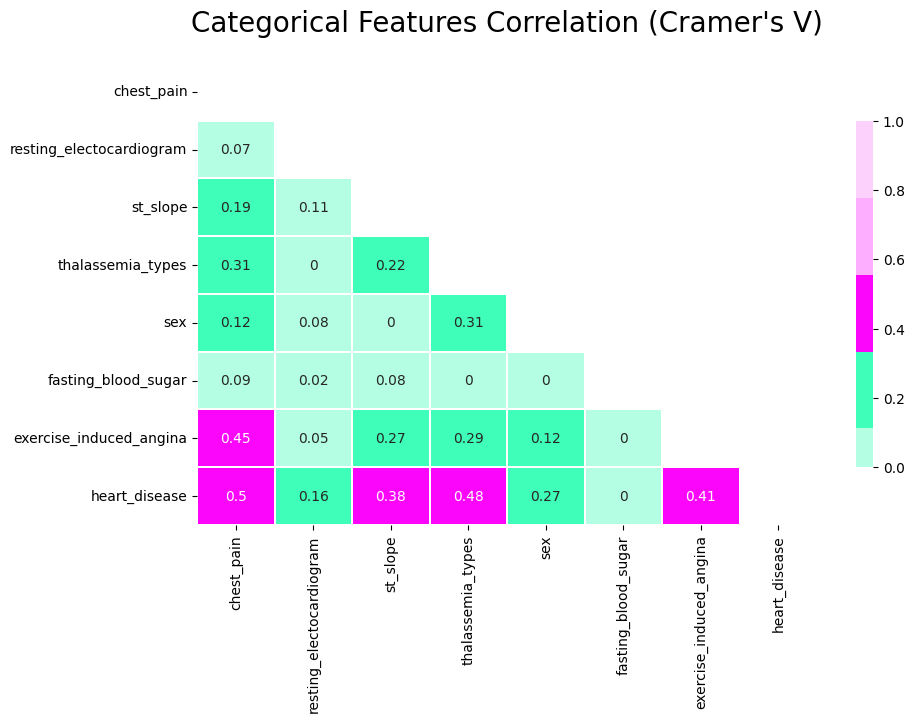

In [44]:
# the cramers_v function is copied from https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

# calculate the correlation coefficients using the above function
data_ = data[cat_feats]
rows= []
for x in data_:
    col = []
    for y in data_ :
        cramers =cramers_v(data_[x], data_[y])
        col.append(round(cramers,2))
    rows.append(col)

cramers_results = np.array(rows)
df = pd.DataFrame(cramers_results, columns = data_.columns, index = data_.columns)

# color palette
mypal_1= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA', '#FC05FB', '#FEAEFE', '#FCD2FC']
# plot the heat map
mask = np.triu(np.ones_like(df, dtype=bool))
corr = df.mask(mask)
f, ax = plt.subplots(figsize=(10, 6), facecolor=None)
cmap = sns.color_palette(mypal_1, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=0, center=0, annot=True,
            square=False, linewidths=.01, cbar_kws={"shrink": 0.75})
ax.set_title("Categorical Features Correlation (Cramer's V)", fontsize=20, y= 1.05);

## **1.5 EDA Summary**: <a class="anchor" id="1.5"></a>

* Data size: 303 rows and 14 columns (13 independent + one target variable) > later reduced to 296 after removing faulty data points!
* Data has no missing values
* Features (columns) data type:
    * Six features are numerical
    * The rest (seven features) are categorical variables
* Target variable is fairly balanced, 54% no-disease to 46% has-disease
* Correlations:
    * Correlation between features is weak at best
    * From the numerical features `num_major_vessels`, `max_heart_rate_achieved` and `st_depression` are reasonabily fairly correlated with the target variable at -0.47, 0.43 and -0.43 correlation coefficient respectively.
    * From the categorical features `chest_pain_type`, `num_major_vessels`, `thalassemia`, and `exercise_induced_angina` are better correlated with the target variable, `thalassemia` being the highest at 0.52.
    * Cholestrol (to my surprize, but what do I know?) has less correlation with heart desease.
    
**Takeaway**: features that have higher predictive power could be, **`chest_pain_type`, `num_major_vessels`, `thalassemia`, `exercise_induced_angina` `max_heart_rate_achieved`** and **`st_depression`**. We will see which features will appear as imporatnt by the classification models.
            

---
# 2. **Predictions** <a class="anchor" id="2"></a>
---
**Note** : We have only 297 case (after data cleaning) which is a very small amount of data to do any serious prediction. Therefore, any conclusion made must be taken with cautions. This notebook is merely an excercise on binary classification algorithms.

## 2.1 **Scikit Learn Classifiers** <a class="anchor" id="2.1"></a>

This is a binary classification problem (has-disease or no-disease cases). Scikit learn offers a wide range of classification algorithms and is often the starting point in most/traditional machine learning challenges, so we start by exploring few of the classification alorithms from the sklearn libarary such as `Logistic Regression`, `Nearest Neighbors`, `Support Vectors`, `Nu SVC`, `Decision Tree`, `Random Forest`, `AdaBoost`, `Gradient Boosting`, `Naive Bayes`, `Linear Discriminant Analysis`, `Quadratic Discriminant Analysis` and `Neural Net`. Let's first build simple models using the above mentioned ML algorithms and later we will optimize them by tuning the parameters.

In [45]:
def label_encode_cat_features(data, cat_features):
    '''
    Given a dataframe and its categorical features, this function returns label-encoded dataframe
    '''

    label_encoder = LabelEncoder()
    data_encoded = data.copy()

    for col in cat_features:
        # Convert all values in the column to string type to ensure uniformity for LabelEncoder
        data_encoded[col] = data_encoded[col].astype(str)
        data_encoded[col] = label_encoder.fit_transform(data_encoded[col])

    data = data_encoded

    return data


def score_summary(names, classifiers, X, y, cv):
    '''
    Given a list of classifiers, this function calculates the accuracy,
    ROC_AUC, Recall, Precision, and F1 scores using cross-validation
    and returns the averaged values in a dataframe.
    '''

    cols=["Classifier", "Accuracy", "ROC_AUC", "Recall", "Precision", "F1"]
    data_table = pd.DataFrame(columns=cols)

    for name, clf in zip(names, classifiers):
        accuracy_scores = []
        roc_auc_scores = []
        recall_scores = []
        precision_scores = []
        f1_scores = []

        for train_index, val_index in cv.split(X, y):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]

            clf.fit(X_train, y_train)
            pred = clf.predict(X_val)
            pred_proba = clf.predict_proba(X_val)[:, 1]

            accuracy_scores.append(accuracy_score(y_val, pred))

            fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
            roc_auc_scores.append(auc(fpr, tpr))

            cm = confusion_matrix(y_val, pred)

            # Handle potential ZeroDivisionError
            recall = cm[1,1]/(cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) != 0 else 0
            precision = cm[1,1]/(cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) != 0 else 0
            f1 = 2*recall*precision/(recall + precision) if (recall + precision) != 0 else 0

            recall_scores.append(recall)
            precision_scores.append(precision)
            f1_scores.append(f1)

        df = pd.DataFrame([[name, np.mean(accuracy_scores)*100, np.mean(roc_auc_scores),
                            np.mean(recall_scores), np.mean(precision_scores), np.mean(f1_scores)]], columns=cols)
        data_table = pd.concat([data_table, df], ignore_index=True)

    return np.round(data_table.reset_index(drop=True), 2)

def roc_auc_curve(names, classifiers, X, y, cv):
    '''
    Given a list of classifiers, this function plots the ROC curves.
    For simplicity, it uses the first split from cross-validation for plotting.
    '''
    plt.figure(figsize=(12, 8))

    # Use the first split for plotting ROC curves
    # This is a simplification; for a full CV ROC, more complex averaging is needed.
    for train_index, val_index in cv.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        break # Only take the first split

    for name, clf in zip(names, classifiers):
        clf.fit(X_train, y_train)

        pred_proba = clf.predict_proba(X_val)[:, 1]

        fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=3, label= name +' ROC curve (area = %0.2f)' % (roc_auc))
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic (ROC) curves', fontsize=20)
    plt.legend(loc="lower right")
    plt.show()

--- Cross-Validation Scores ---


,Classifier,Accuracy,ROC_AUC,Recall,Precision,F1
0,Logistic Regression,84.79,0.91,0.89,0.85,0.86
1,Nearest Neighbors,56.77,0.61,0.40,0.67,0.49
2,Decision Tree,72.97,0.73,0.72,0.77,0.74
3,Random Forest,83.11,0.91,0.87,0.84,0.85
4,Gradient Boosting,78.05,0.88,0.80,0.80,0.80



--- ROC Curves (from one CV split) ---


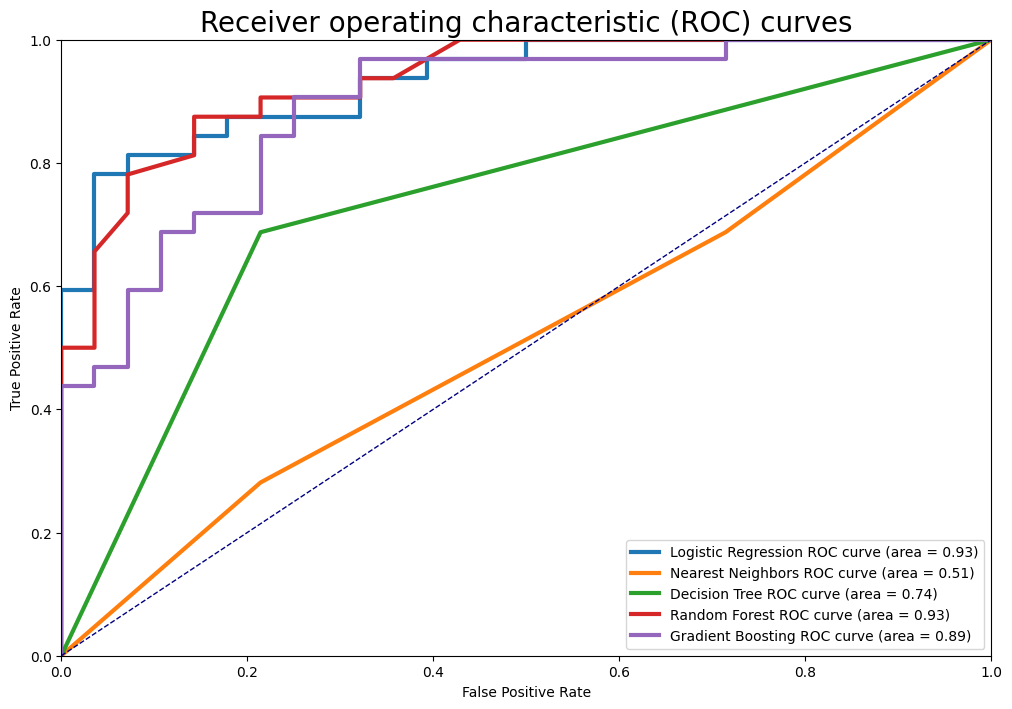

In [46]:
# split the data into train and test sets
from sklearn.model_selection import StratifiedKFold

cat_features = cat_feats
data = label_encode_cat_features(data, cat_features)

seed = 0
# test_size = 0.25 # Not directly used for cross-validation for splitting anymore

features = data.columns[:-1]

X = data[features]
y = data['heart_disease']

# Initialize StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = test_size, random_state=seed) # Removed single split

# classifier algorithms with default parameters

names = [
    'Logistic Regression',
    'Nearest Neighbors',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

classifiers = [
    LogisticRegression(solver="liblinear", random_state=seed),
    KNeighborsClassifier(n_neighbors=2),
    DecisionTreeClassifier(random_state=seed),
    RandomForestClassifier(random_state=seed),
    GradientBoostingClassifier(random_state=seed),
]

# Call score_summary and roc_auc_curve with cross-validation
print("--- Cross-Validation Scores ---")
scores_df = score_summary(names, classifiers, X, y, cv)
display(scores_df)

print("\n--- ROC Curves (from one CV split) ---")
roc_auc_curve(names, classifiers, X, y, cv)

### 2.1.1 Performance metric

There are several metrics that can be used to gauge the performance of a given classification algorithm. The choice of the '*appropriate*' metrics is then dependent on the type of problem we are dealing with. There are case where, for example, *accuracy* can be the right choice and in some other case a *recall* or *precision* could be more fitting to the purpose. Since we are dealing with medical case (classify if a case is positive for heart disease or not), we could use recall (true positive rate or sensitivity) as performance metrics to choose our classifier. Note here that we do not want to classify positive (has disease) cases as negative (no disease).

**Confusion matrix** : A confusion matrix (aka an error matrix) is a specific table layout that allows visualization of the performance of a supervised learning algorithm. Each row of the matrix represents the instances in an *actual* class while each column represents the instances in a *predicted* class [[wiki](https://en.wikipedia.org/wiki/Confusion_matrix)]. The table below is an example of a confusion matrix for a binary classification from which other terminologies/metric can be derived. Some of the metrics are described below.

<div>    
<img src="https://miro.medium.com/max/875/1*LQ1YMKBlbDhH9K6Ujz8QTw.jpeg" width="350", align="center"/>  
</div>

[Image credit >>](https://towardsdatascience.com/demystifying-confusion-matrix-29f3037b0cfa)

---

**Key**:

|**Term** |**Meaning** | **Descriptions**|
| --- |---|---|
|TP |True Positive|Positive cases which are predicted as positive|
|FP |False Positive|Negative cases which are predicted as positive|
|TN |True Negative|Negative cases which are predicted as negative|
|FN |False Negative|Positive casea which are predicted as negative|

---
**Accuracy** : Measures how many of the cases are correctly identified/predicted by the model, i.e correct prediction divided by the total sample size.

$\frac{TP + TN}{TP +TN + FP + FN}$

**Recall**: Measures the rate of *true positives*, i.e how many of the *actual* positive cases are *identified/predicted* as positive by the model.

$\frac{TP}{(TP + FN)}$

**Precision**: Measures how many of the positive predicted cases are actually positive.

$\frac{TP}{(TP + FP)}$

**F1-Score** : Combines the precision and recall of the model and it is defined as the harmonic mean of the model’s precision and recall.

$2\frac{recall * precision}{recall + precision}$

**ROC curves** : A receiver operating characteristic (ROC) curve, is a graphical plot which illustrates the performance of a binary classification algorithm as a function of ture positive rate and false positive rate.

### 2.1.2 Performance metrics summary table

In [49]:
score_summary(names, classifiers, X, y, cv).sort_values(by='Accuracy' , ascending = False)\
.style.background_gradient(cmap='coolwarm')\
.bar(subset=["ROC_AUC",], color='#6495ED')\
.bar(subset=["Recall"], color='#ff355d')\
.bar(subset=["Precision"], color='lightseagreen')\
.bar(subset=["F1"], color='gold')

,Classifier,Accuracy,ROC_AUC,Recall,Precision,F1
0,Logistic Regression,84.790000,0.910000,0.890000,0.850000,0.860000
3,Random Forest,83.110000,0.910000,0.870000,0.840000,0.850000
4,Gradient Boosting,78.050000,0.880000,0.800000,0.800000,0.800000
2,Decision Tree,72.970000,0.730000,0.720000,0.770000,0.740000
1,Nearest Neighbors,56.770000,0.610000,0.400000,0.670000,0.490000


### 2.1.3 ROC curves

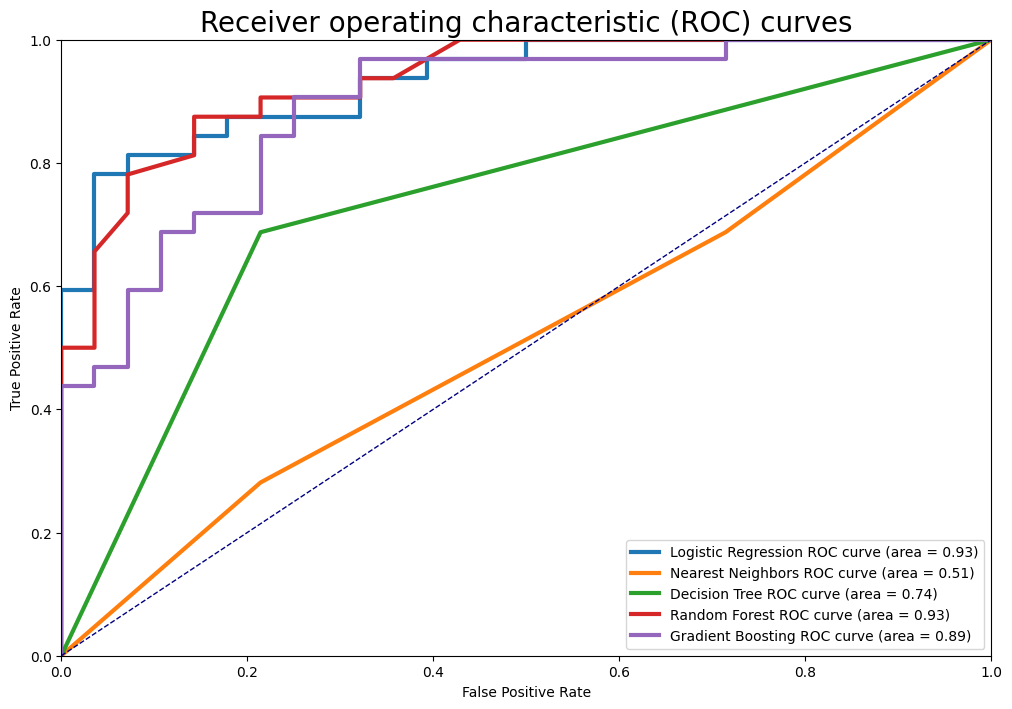

In [51]:
roc_auc_curve(names, classifiers, X, y, cv)

### 2.1.4 Confusion matrix

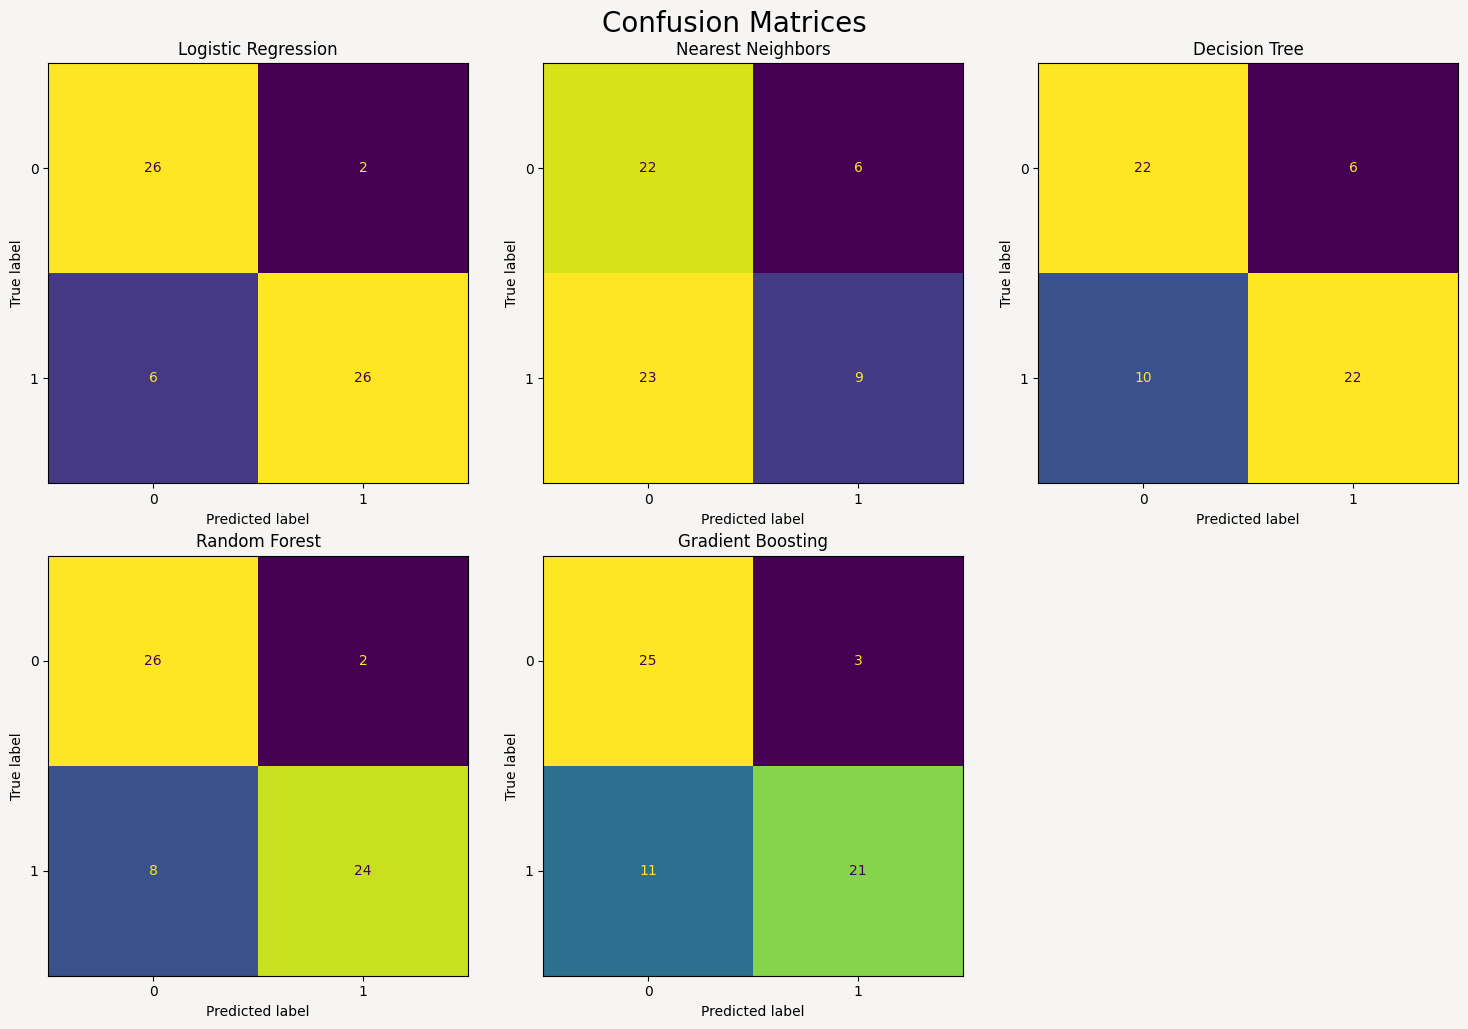

In [54]:
def plot_conf_matrix(names, classifiers, X, y, cv, nrows, ncols, fig_a, fig_b):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_a, fig_b), facecolor='#F6F5F4')
    axes = axes.flatten()

    # Use the first split for plotting confusion matrices
    for train_index, val_index in cv.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        break # Only take the first split

    for i, (name, clf) in enumerate(zip(names, classifiers)):
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)
        cm = confusion_matrix(y_val, y_pred, labels=clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
        disp.plot(ax=axes[i], cmap='viridis', colorbar=False)
        axes[i].set_title(name)
        axes[i].set_xlabel('Predicted label')
        axes[i].set_ylabel('True label')

    # Hide any unused subplots
    for j in range(i + 1, nrows * ncols):
        axes[j].set_visible(False)

    fig.tight_layout()
    plt.suptitle('Confusion Matrices', y=1.02, fontsize=20)
    plt.show()

plot_conf_matrix(names, classifiers, X, y, cv, nrows=2, ncols=3, fig_a=15, fig_b=10)

Now we have seen all the performance metrics of the classifiers, it is decision time for us to choose the best possible classifier algorithm. Based on precision LR ranks first (86%); whereas if we see the recall, Neural Nets ranks first with 94%. In the case of precision, QDA ranks first with 85%. So which one to choose? The F1-score can give us a balance between recall and precision. LR happens to have the best F1-score so we choose Logistic Regression as our best classifier.

**Note**: If I were consulting a clinic doing a heart disease screening test, I would like to strike a perfect balance between precision and recall (I don't want the clinic to risk their reputation of by handing out too many false positive result but all without risking their clients' health by predicting too many false negatives). Therefore, I would advice them to choose the model which gives a higher F1-score, i.e the Logistic regression model.

### 2.1.5 Parameter Tuning (RandomizedSearch): LogisticRegression

So chosen our best classifier, the Logistic regression model. However, this was achieved with default parameters. The intuition is that we could further improve our model with tuned parameters. Let's see if could achieve that using the scikit-learn RandomizedSearch algorithm.  

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

lr = LogisticRegression(tol=1e-4, max_iter=1000, random_state=seed)

space = dict(C=uniform(loc=0, scale=5),
                     penalty=['l2', 'l1'],
                     solver= ['liblinear'])

search = RandomizedSearchCV(lr,
                         space,
                         random_state=seed,
                         cv = cv,
                         scoring='f1')

rand_search = search.fit(X, y)

print('Best Hyperparameters: %s' % rand_search.best_params_)

Best Hyperparameters: {'C': np.float64(0.2835648865872159), 'penalty': 'l2', 'solver': 'liblinear'}


In [58]:
params = rand_search.best_params_
lr = LogisticRegression(**params)

# Create a fresh train-test split for this evaluation of the tuned model
from sklearn.model_selection import train_test_split
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

lr.fit(X_train_split, y_train_split)
print(classification_report(y_val_split, lr.predict(X_val_split)))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83        34
           1       0.84      0.90      0.87        40

    accuracy                           0.85        74
   macro avg       0.85      0.85      0.85        74
weighted avg       0.85      0.85      0.85        74



**Remark** : It turns out that our base model (default params) is not bad at all. Parameter tuning did not help to further increase the performance.

## 2.2 **Catboost, Lgbm and Xgboost** <a class="anchor" id="2.2"></a>

In the above section (&&2.1) we have seen classifiers out of the scikit-learn library. Now we will try the modern (boosted trees) ML algorithms such as the [**catboost**](https://catboost.ai/), [**xgboost**](https://xgboost.readthedocs.io/en/stable/#) and [**lgbm**](https://lightgbm.readthedocs.io/en/latest/index.html). They are optimized machine learning algorithms based on the [**gradient-boosting**](https://en.wikipedia.org/wiki/Gradient_boosting) technique. Depending on the problem at hand, one algorithm is may be better suited than others. For detailed info one can easily refer to their documentations.

In [59]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

names_boost =[
    'xgbbost',
    'light GBM'
]
classifiers = [
    XGBClassifier(objective= 'binary:logistic', random_state=seed),
    LGBMClassifier(random_state=seed)
   ]

### 2.2.1 Performance metrics summary table

In [66]:
import warnings
warnings.filterwarnings('ignore')
score_summary(names_boost, classifiers, X, y, cv).sort_values(by='Accuracy' , ascending = False)\
.style.background_gradient(cmap='coolwarm')\
.bar(subset=["ROC_AUC",], color='#6495ED')\
.bar(subset=["Recall"], color='#ff355d')\
.bar(subset=["Precision"], color='lightseagreen')\
.bar(subset=["F1"], color='gold')

[LightGBM] [Info] Number of positive: 128, number of negative: 108
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 235
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542373 -> initscore=0.169899
[LightGBM] [Info] Start training from score 0.169899
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,Classifier,Accuracy,ROC_AUC,Recall,Precision,F1
1,light GBM,80.080000,0.890000,0.840000,0.800000,0.820000
0,xgbbost,79.070000,0.880000,0.810000,0.800000,0.800000


### 2.2.2 Confusion matrix

[LightGBM] [Info] Number of positive: 128, number of negative: 108
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 235
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542373 -> initscore=0.169899
[LightGBM] [Info] Start training from score 0.169899
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

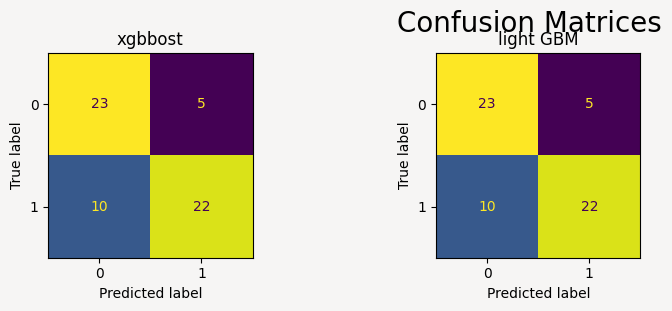

In [67]:
plot_conf_matrix(names=names_boost, classifiers=classifiers, X=X, y=y, cv=cv, nrows=1, ncols=3, fig_a=12, fig_b=3);

**Remark** : Here we can see that the lgbm calssifier is marginally better than the other two and we will go for it. Following the same procedure, we will try to tune the parameters in the next section.

### 2.2.3 Parameter Tuning (RandomizedSearch): LGBMClassifier

In [69]:
from sklearn.model_selection import GridSearchCV
rs_params = {
    'num_leaves': [20, 100],
    'max_depth': [5, 15],
    'min_data_in_leaf': [80, 120],
}
rs_cv = GridSearchCV(estimator=LGBMClassifier(random_state=seed, verbose=-1),
                           param_grid=rs_params,
                           cv = 5)

rs_cv.fit(X, y)
params = rs_cv.best_params_
params

{'max_depth': 5, 'min_data_in_leaf': 80, 'num_leaves': 20}

In [71]:
lgbm = LGBMClassifier(**params);

lgbm.fit(X_train_split, y_train_split,
        eval_set=(X_val_split, y_val_split)
);

print(classification_report(y_val_split, lgbm.predict(X_val_split)))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        34
           1       0.85      0.85      0.85        40

    accuracy                           0.84        74
   macro avg       0.84      0.84      0.84        74
weighted avg       0.84      0.84      0.84        74



**Remark**: In this case (Lgbm) hyper-parameter tuning gave better results than the base model. We have increased the recall value from 86% to 94%. Which means we have decrease the rate of false negatives from 5 cases to 2 in our validation set and we have also decreased the false positive cases by 1. Marginal but we will take every percentage point we can get.

## 2.3 **Model Explainablity** <a class="anchor" id="2.3"></a>

One of the challenges of a machine leaning project is explaining the model's prediction. A model might consider some features more important than other for its prediction. Another model might weigh other features as more important. **Permutation importance** and **SHAP** are two methods one can use to understand which features were selected to have the most impact on our model's prediction.

### 2.3.1 Permutation importance:
The permutation importance is defined to be the **decrease in a model score** when a **single feature value** is *randomly shuffled*. The procedure breaks the relationship between the *feature* and the *target*, thus the drop in the **model score** is indicative of how much the model depends on the feature [[3](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)]. In other words, permutation importance tell us what features have the biggest impact on our model predictions.

### 2.3.2 SHAP:

**SHAP**, a short name for **SH**apely **A**dditive Ex**P**lanations, is a method used to explain the output of a machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions [[5](https://shap.readthedocs.io/en/latest/index.html)]. SHAP has a rich functionality (methods) by which we can visualize/interpret the output of our models. Below we use the `shap.summary_plot()` to identify the impact each feature has on the predicted output.

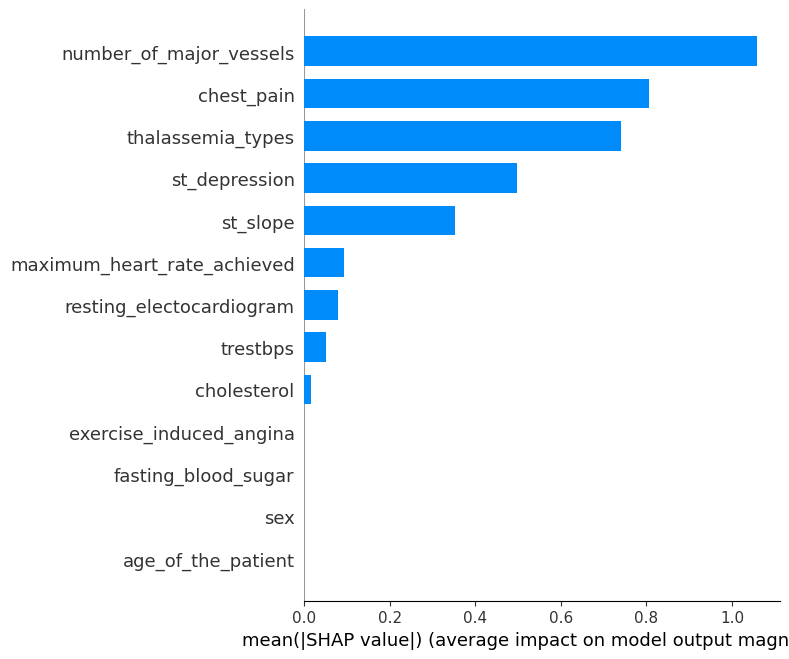

In [73]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_val_split)
shap.summary_plot(shap_values, X_val_split,
                  feature_names=features,
                  plot_type="bar",
                 )